# Corelation and Covariance

# What are Outliers?
* Outliers are data values that are very different from the other values in a dataset.
* They may occur because of measurement errors, data entry mistakes, unusual events, or genuine exceptional cases
## real time example
* Suppose the salaries of employees are 25000, 28000, 30000, 32000, 35000, 200000. Here, 200000 is an outlier
* because it is much higher than the other salaries
### example


In [1]:
import numpy as np

salary = np.array([25000, 28000, 30000, 32000, 35000, 200000])

mean = np.mean(salary)

print("Mean:", mean)

Mean: 58333.333333333336


# Types of Outliers
* Outliers can occur in different forms depending on how and where they appear in the data.

* common outliers are:
* Univariate Outlier – unusual value in one variable.
* Multivariate Outlier – unusual combination of values across multiple variables.
* Global Outlier – a value that is very different from the entire dataset.
* Contextual Outlier – a value that is unusual only in a particular situation or context.

## real time example
* Univariate:
Employee salary = ₹10,00,000 while most salaries are around ₹30,000.

* Multivariate:
A customer has unusually high income but extremely low spending compared with other customers.

* Contextual:
Electricity usage of 500 units may be normal for a factory but unusual for a small house.


### example


In [4]:
import pandas as pd

marks = [45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 150]

data = pd.DataFrame({"Marks": marks})

print(data)

    Marks
0      45
1      50
2      55
3      60
4      65
5      70
6      75
7      80
8      85
9      90
10     95
11    150


* here it is a univariate outlier because of we are checking only one variable


# Detecting Outliers
* Outlier detection is the process of identifying values that are significantly different from the normal pattern of the dataset.
* some methods are:
IQR Method

Z-Score Method

Box Plot

Scatter Plot

### Real-time Example
for example

10, 12, 15, 14, 13, 16, 100

The value 100 is likely an outlier because it is much larger than the other values.

### formula
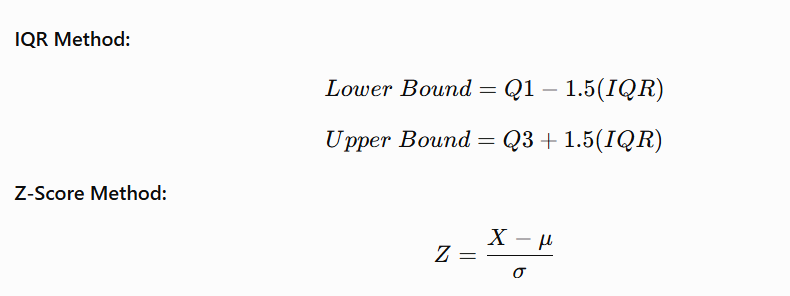

In [6]:
print(data.describe())

            Marks
count   12.000000
mean    76.666667
std     27.988093
min     45.000000
25%     58.750000
50%     72.500000
75%     86.250000
max    150.000000


# IQR Method

* The IQR (Interquartile Range) Method detects outliers by looking at the middle 50% of the data.

* IQR is the difference between the third quartile and first quartile.

### Real-time Example

* Data:10, 12, 14, 15, 16, 18, 20, 50

* Here 50 may be detected as an outlier because it is far away from the middle values.

### Formula
$$ IQR = Q3-Q1 $$
Lower Bound:
$$ Q1-1.5(IQR) $$
Upper Bound:
$$ Q3+1.5(IQR) $$
$$ X < Lower\ Bound $$
$$ X > Upper\ Bound $$
is considered an outlier.

In [7]:
Q1 = data["Marks"].quantile(0.25)
Q3 = data["Marks"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data["Marks"] < lower) | (data["Marks"] > upper)]

print(outliers)

    Marks
11    150


#  Z-Score Method
* The Z-Score Method identifies how far a data value is from the mean in terms of standard deviations.
* A very large positive or negative Z-score indicates a possible outlier.

### Real-time Example

* Suppose the average employee salary is ₹30,000 and one employee earns ₹2,00,000.

* That salary is many standard deviations away from the average and may be an outlier.

### Formula
$$ Z=\frac{X-\mu}{\sigma} $$

Where:

X= data value

μ = mean

σ= standard deviation

$$ |Z| > 3 $$

is considered a possible outlier.

In [9]:
import numpy as np
from scipy.stats import zscore

data = np.array([10, 12, 14, 15, 16, 18, 20, 100])

z_scores = zscore(data)

outliers = data[np.abs(z_scores) > 3]

print("Z-Scores:", z_scores)

Z-Scores: [-0.55277817 -0.48202256 -0.41126696 -0.37588915 -0.34051135 -0.26975575
 -0.19900014  2.63122408]


# Box Plot
* A Box Plot is a statistical graph used to show the distribution of data and identify possible outliers.
* It displays
  
Minimum

Q1

Median

Q3

Maximum

Outliers
### Real-time Example

* A company wants to compare employee salaries
* A box plot can quickly show whether some employees have salaries that are unusually high or low.

### Formula

$$ IQR=Q3-Q1 $$ $$ Lower=Q1-1.5(IQR) $$
$$ Upper=Q3+1.5(IQR)$$

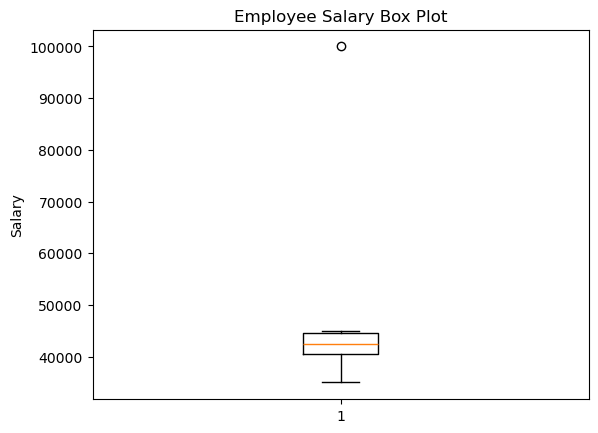

In [14]:
import numpy as np
import matplotlib.pyplot as plt

salary = np.array([40000, 45000, 42000, 43000, 35000, 100000])

data = pd.DataFrame({"Salary": salary})
plt.boxplot(data["Salary"])
plt.ylabel("Salary")
plt.title("Employee Salary Box Plot")
plt.show()


# Scatter plot
* A Scatter Plot displays individual data points to show the relationship between two variables.
* It helps to identify

* Relationships
* Patterns
* Clusters
* Possible outliers


### Real-time Example
* comparing with Advertising Cost vs Sales
* If most points follow a pattern but one point is very far away from the others, that point may be an outlier

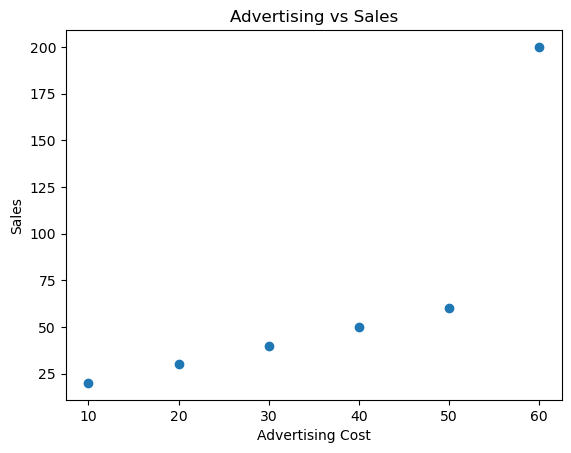

In [15]:
import numpy as np
import matplotlib.pyplot as plt

advertising = np.array([10, 20, 30, 40, 50, 60])
sales = np.array([20, 30, 40, 50, 60, 200])

plt.scatter(advertising, sales)
plt.xlabel("Advertising Cost")
plt.ylabel("Sales")
plt.title("Advertising vs Sales")
plt.show()